In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
from numba import cuda
from tabulate import tabulate

In [2]:
# Количество потоков в блоке (Thread Per Block) для GPU
TPB = 16

# Количество итераций для усреднения времени выполнения
ITER = 70

# Небольшая константа для избежания деления на ноль
EPS = 10e-8

In [3]:
# Декоратор, указывающий, что функция будет выполняться на GPU с использованием Numba
@cuda.jit
def gpu_vec_sum(vec, res):
    tx = cuda.threadIdx.x  # Индекс потока в блоке
    bx = cuda.blockIdx.x   # Индекс блока
    idx = tx + bx * TPB    # Индекс элемента в массиве

    if idx < vec.shape[0]:
        cuda.atomic.add(res, 0, vec[idx])

In [4]:
# Функция для проведения измерений на CPU и GPU
def calculation():
    rows = []
    vec_size_min = 50000
    vec_size_max = 1000000
    vec_size_interval = 50000

    for vec_size in range(vec_size_min, vec_size_max + 1, vec_size_interval):
        cpu_time_sum = 0.
        gpu_time_sum = 0.

        for _ in range(ITER):
            vec = np.ones(vec_size)
            res = np.zeros(1, dtype=np.int32)

            d_vec = cuda.to_device(vec)  # Отправляем вектор на GPU
            d_res = cuda.to_device(res)  # Создаем массив для результата на GPU

            start = time.time()

            # Вызываем функцию на GPU для суммирования
            gpu_vec_sum[int((vec_size + TPB) / TPB), TPB](d_vec, d_res)

            gpu_time_sum += time.time() - start

            res = d_res.copy_to_host()  # Копируем результат с GPU на CPU

            start = time.time()
            real_res = np.sum(vec)  # Выполняем суммирование на CPU
            cpu_time = time.time() - start
            cpu_time_sum += cpu_time

        row = [vec_size,  cpu_time_sum / ITER, gpu_time_sum / ITER]
        rows.append(row)

    # Выводим результаты в виде таблицы
    print(tabulate(rows, headers=['vector size', 'cpu, ms', 'gpu, ms']))
    return rows

In [5]:
# Функция для построения графиков
def plots(vec_array, cpu_time_array, gpu_time_array, acceleration_array):
    # График времени работы программы на CPU
    plt.figure()
    plt.title("CPU")
    plt.plot(vec_array, cpu_time_array)
    plt.xlabel("размер вектора")
    plt.ylabel("время, мс")
    plt.grid()

    # График времени работы программы на GPU
    plt.figure()
    plt.title("GPU")
    plt.plot(vec_array, gpu_time_array)
    plt.xlabel("размер вектора")
    plt.ylabel("время, мс")
    plt.grid()

    # График ускорения вычислений на GPU относительно CPU
    plt.figure()
    plt.title("Ускорение")
    plt.plot(vec_array, acceleration_array)
    plt.xlabel("размер вектора")
    plt.grid()
    plt.show()

## Запуск измерений

Запусти эту ячейку, когда все предыдущие ячейки выполнены. Она проведёт измерения CPU/GPU и построит графики.

  vector size      cpu, ms      gpu, ms
-------------  -----------  -----------
        50000  7.30651e-05  0.00466285
       100000  6.59159e-05  7.13723e-05
       150000  7.19275e-05  0.000178994
       200000  0.000109223  0.000161222
       250000  0.000178432  0.000136409
       300000  0.000210476  0.000210789
       350000  0.000263514  0.000179056
       400000  0.000256375  0.000165575
       450000  0.000436817  0.000199117
       500000  0.000379644  0.000150405
       550000  0.00027317   0.00015706
       600000  0.000494187  0.000246208
       650000  0.000542712  0.000143514
       700000  0.000515018  0.00016629
       750000  0.000542699  0.000141246
       800000  0.000526009  0.000200513
       850000  0.000827694  0.000175759
       900000  0.000778757  0.0001708
       950000  0.000775296  0.000167833
      1000000  0.000669752  0.000186341


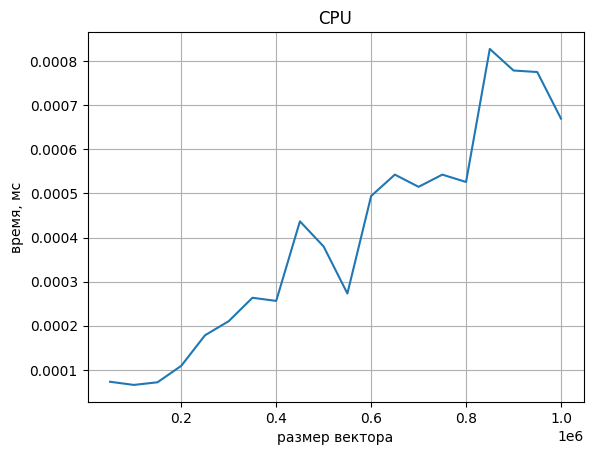

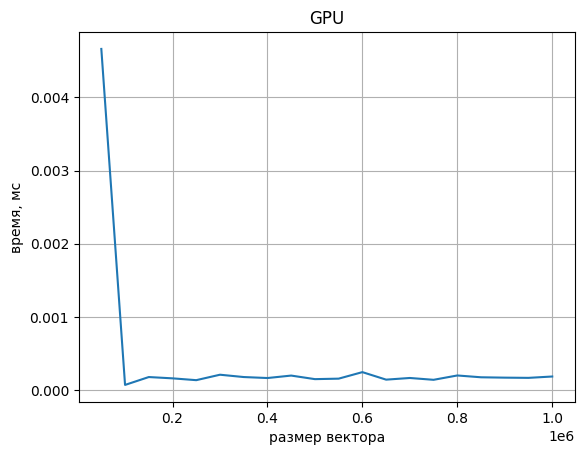

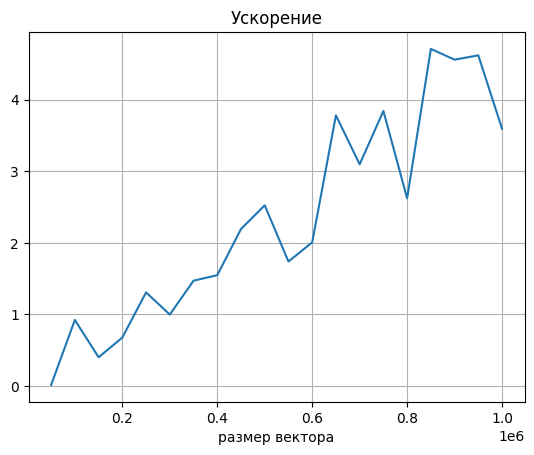

In [6]:
# Выполняем измерения и сохраняем результаты
output_data = calculation()

# Данные для построения графиков
vec_array = list(map(lambda x: x[0], output_data))
cpu_time_array = list(map(lambda x: x[1], output_data))
gpu_time_array = list(map(lambda x: x[2], output_data))
acceleration_array = list(map(lambda x: x[1] / (x[2] if x[2] > EPS else EPS), output_data))

# Строим графики
plots(vec_array, cpu_time_array, gpu_time_array, acceleration_array)